# AI Impact on Jobs — Layoff Risk Analysis

**Dataset:** [AI Impact on Jobs and Layoff Risk Dataset](https://www.kaggle.com/datasets/shivasingh4945/ai-impact-on-jobs-and-layoff-risk-dataset) (Kaggle, 20,000 rows, 16 columns)

**Goal:** Explore how AI adoption, task automation, and routine-task exposure relate to layoff risk, and build a classifier that flags employees at high risk.

**Note on the data:** This dataset appears synthetically generated with a fairly explicit rule linking task automation / routine-task percentage to the risk label. Model performance below reflects how well that rule is learned, not real-world generalization — flagged here for transparency rather than presented as a real-world validated model.

**Structure:**
1. Load and inspect data
2. Create binary target (`High_Risk_Flag`)
3. Exploratory Data Analysis
4. Feature engineering
5. Train/test split
6. Model 1 — Logistic Regression (baseline)
7. Model 2 — Random Forest
8. Evaluation — confusion matrices, ROC curves
9. Feature importance
10. Export predictions for SQL / Power BI stages (out-of-sample, via cross-validation)


## 1. Load and inspect data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

df = pd.read_csv("ai-impact-jobs-layoff-risk-dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (20000, 16)


,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Age                         20000 non-null  int64
 1   Education_Level             20000 non-null  str  
 2   Years_of_Experience         20000 non-null  int64
 3   Industry                    20000 non-null  str  
 4   Job_Role                    20000 non-null  str  
 5   Company_Size                20000 non-null  str  
 6   Job_Level                   20000 non-null  str  
 7   Routine_Task_Percentage     20000 non-null  int64
 8   Creativity_Requirement      20000 non-null  int64
 9   Human_Interaction_Level     20000 non-null  int64
 10  AI_Adoption_Level           20000 non-null  str  
 11  Number_of_AI_Tools_Used     20000 non-null  int64
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64
 13  Tasks_Automated_Percentage  20000 non-null  int64
 14  AI_Training_Hours

In [3]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64

Duplicate rows: 0


## 2. Create binary target

The original `Layoff_Risk` column has 3 classes (High / Medium / Low), nearly balanced at ~33% each.
We collapse this to a binary target — **High Risk vs Not High Risk** — for a cleaner, more interview-friendly
classification problem with a clear business framing: "flag employees at high risk of layoff."


In [4]:
df['High_Risk_Flag'] = (df['Layoff_Risk'] == 'High').astype(int)

print(df['High_Risk_Flag'].value_counts())
print(df['High_Risk_Flag'].value_counts(normalize=True).round(3))
# ~66% Not High Risk, ~34% High Risk -> mild imbalance, report F1/recall alongside accuracy

High_Risk_Flag
0    13203
1     6797
Name: count, dtype: int64
High_Risk_Flag
0    0.66
1    0.34
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis

### 3a. Numeric features by risk

In [5]:
numeric_cols = ['Age', 'Years_of_Experience', 'Routine_Task_Percentage',
                 'Creativity_Requirement', 'Human_Interaction_Level',
                 'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week',
                 'Tasks_Automated_Percentage', 'AI_Training_Hours']

df.groupby('High_Risk_Flag')[numeric_cols].mean().round(2)

,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours
High_Risk_Flag,,,,,,,,,
0,40.62,7.56,39.90,60.11,62.18,1.76,4.72,27.59,8.70
1,39.86,6.69,75.17,23.84,55.92,3.81,10.77,55.96,20.24


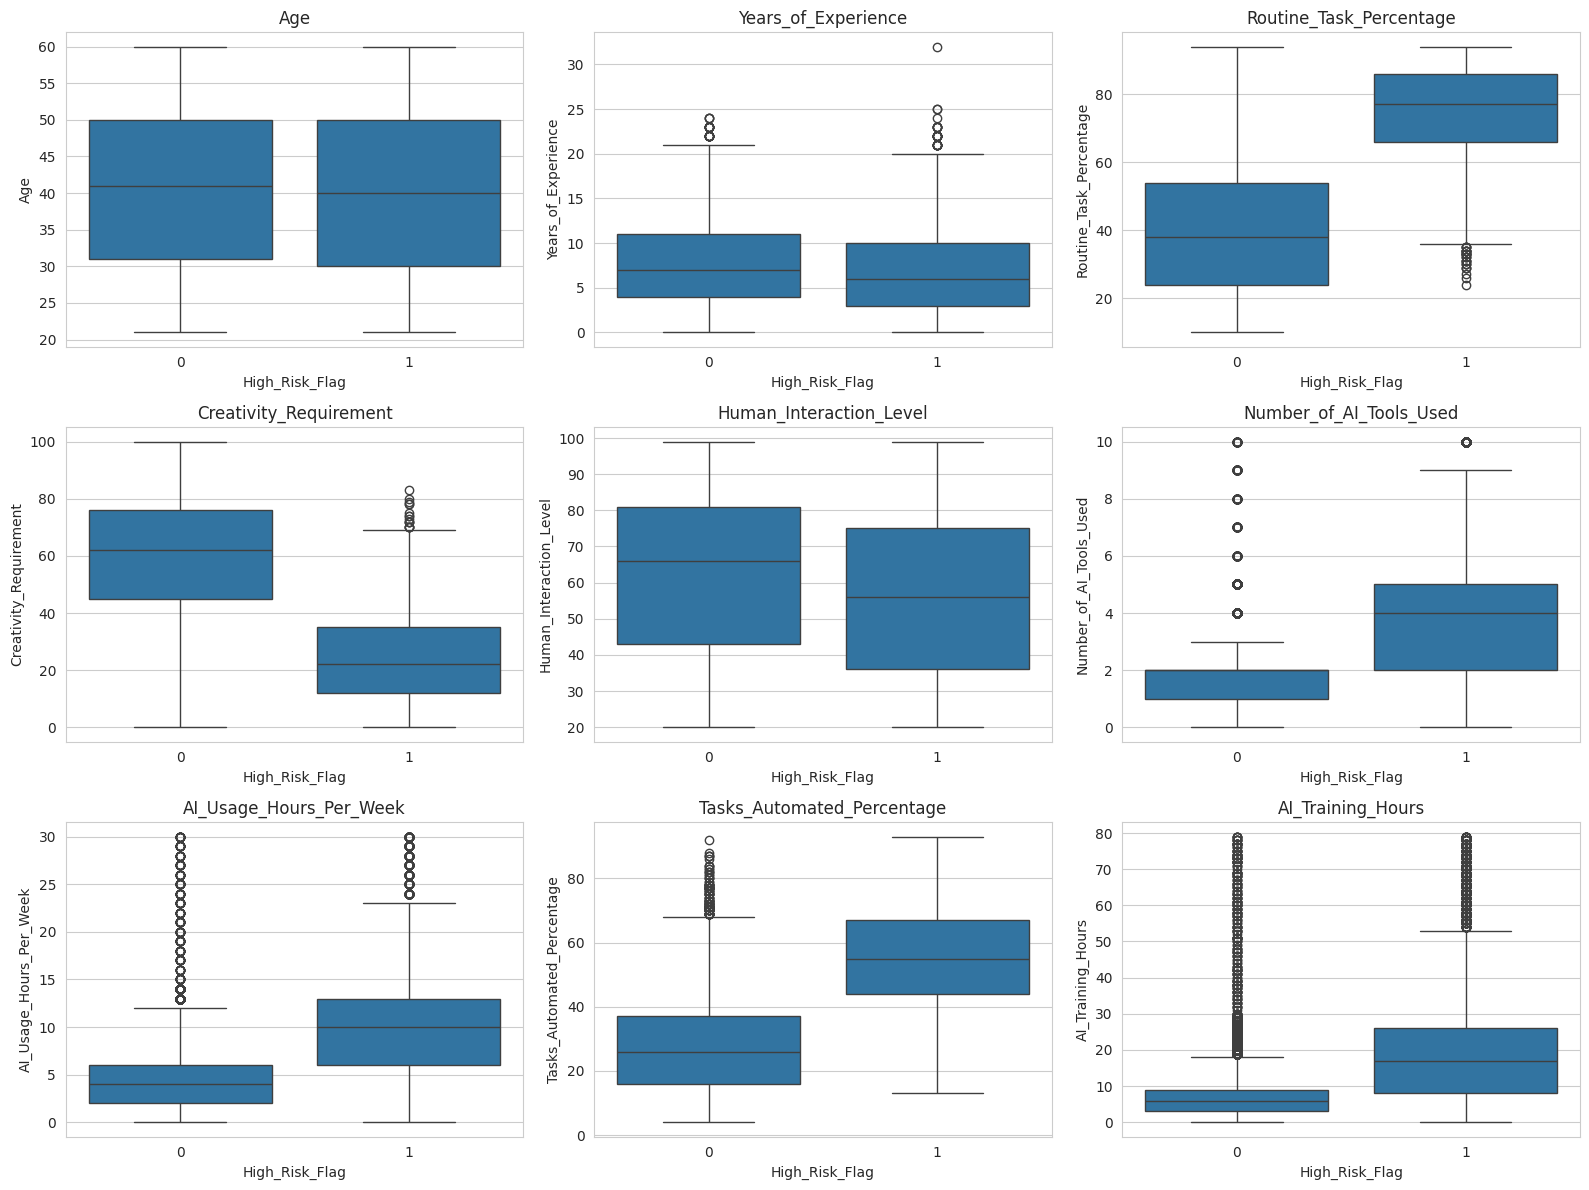

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(data=df, x='High_Risk_Flag', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("eda_numeric_by_risk.png", dpi=120)
plt.show()

### 3b. Categorical breakdowns

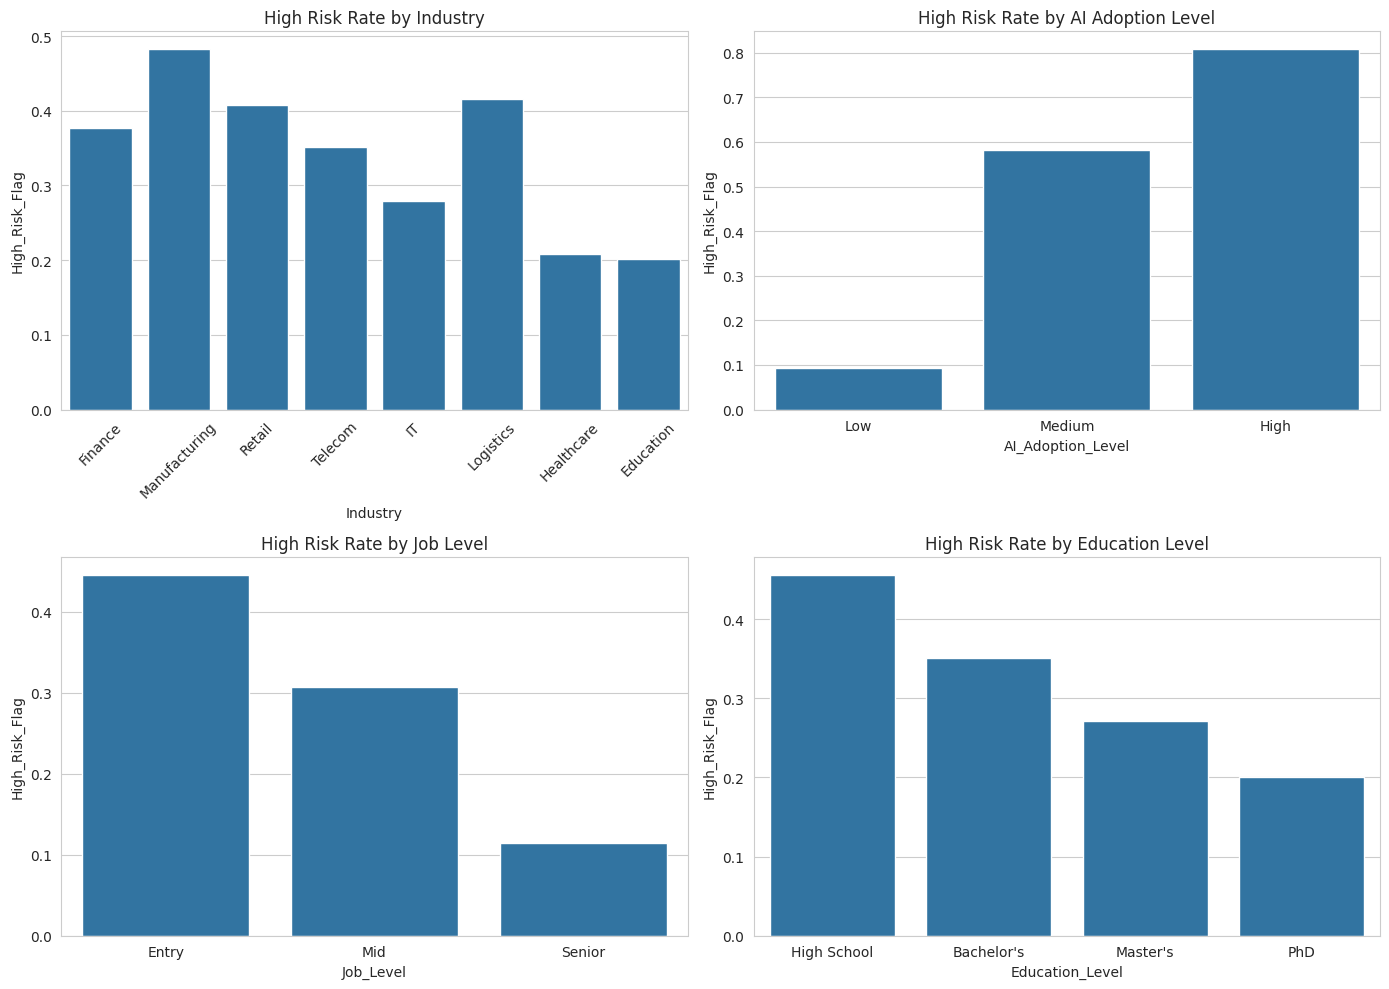

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=df, x='Industry', y='High_Risk_Flag', ax=axes[0,0], errorbar=None)
axes[0,0].set_title("High Risk Rate by Industry")
axes[0,0].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='AI_Adoption_Level', y='High_Risk_Flag',
            order=['Low','Medium','High'], ax=axes[0,1], errorbar=None)
axes[0,1].set_title("High Risk Rate by AI Adoption Level")

sns.barplot(data=df, x='Job_Level', y='High_Risk_Flag',
            order=['Entry','Mid','Senior'], ax=axes[1,0], errorbar=None)
axes[1,0].set_title("High Risk Rate by Job Level")

sns.barplot(data=df, x='Education_Level', y='High_Risk_Flag',
            order=["High School","Bachelor's","Master's","PhD"], ax=axes[1,1], errorbar=None)
axes[1,1].set_title("High Risk Rate by Education Level")

plt.tight_layout()
plt.savefig("eda_categorical_by_risk.png", dpi=120)
plt.show()

**Observations:**
- Manufacturing, Logistics, and Retail show the highest high-risk rates; Education and Healthcare the lowest.
- High AI adoption level correlates strongly with high risk — more AI in a role tends to mean more automatable tasks.
- Entry-level roles carry far higher risk than Senior roles, consistent with real-world layoff patterns.


### 3c. Correlation heatmap

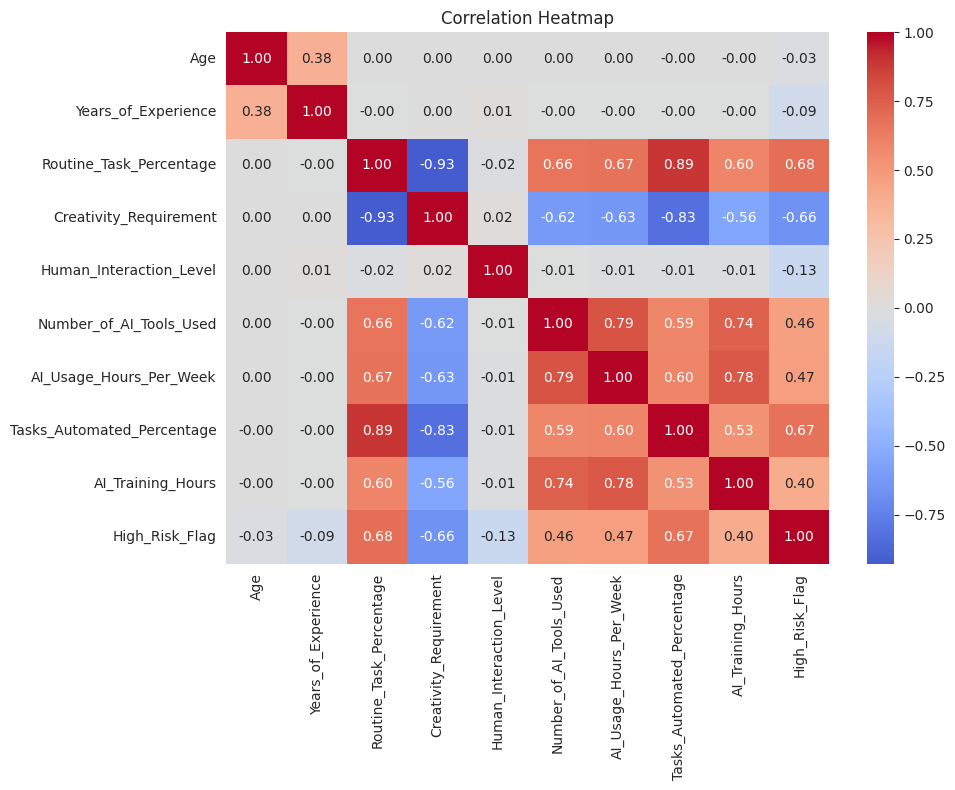

In [8]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols + ['High_Risk_Flag']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=120)
plt.show()

## 4. Feature engineering

- Ordinal categoricals (`Education_Level`, `Job_Level`, `Company_Size`, `AI_Adoption_Level`) are encoded with explicit order, since they have a natural ranking.
- Nominal categoricals (`Industry`, `Job_Role`) are one-hot encoded, since they have no natural order.
- An engineered feature, `Automation_Exposure_Ratio`, captures how much a role's automatable workload outweighs its human-skill demands.


In [9]:
model_df = df.copy()

education_map = {"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3}
joblevel_map = {"Entry": 0, "Mid": 1, "Senior": 2}
size_map = {"Small": 0, "Medium": 1, "Large": 2}
adoption_map = {"Low": 0, "Medium": 1, "High": 2}

model_df['Education_Level_enc'] = model_df['Education_Level'].map(education_map)
model_df['Job_Level_enc'] = model_df['Job_Level'].map(joblevel_map)
model_df['Company_Size_enc'] = model_df['Company_Size'].map(size_map)
model_df['AI_Adoption_Level_enc'] = model_df['AI_Adoption_Level'].map(adoption_map)

model_df = pd.get_dummies(model_df, columns=['Industry', 'Job_Role'], drop_first=True)

model_df['Automation_Exposure_Ratio'] = (
    model_df['Tasks_Automated_Percentage'] /
    (model_df['Creativity_Requirement'] + model_df['Human_Interaction_Level'] + 1)
)

drop_cols = ['Education_Level', 'Company_Size', 'Job_Level', 'AI_Adoption_Level', 'Layoff_Risk']
model_df = model_df.drop(columns=drop_cols)

print("Final feature set shape:", model_df.shape)
model_df.columns.tolist()

Final feature set shape: (20000, 45)


['Age',
 'Years_of_Experience',
 'Routine_Task_Percentage',
 'Creativity_Requirement',
 'Human_Interaction_Level',
 'Number_of_AI_Tools_Used',
 'AI_Usage_Hours_Per_Week',
 'Tasks_Automated_Percentage',
 'AI_Training_Hours',
 'High_Risk_Flag',
 'Education_Level_enc',
 'Job_Level_enc',
 'Company_Size_enc',
 'AI_Adoption_Level_enc',
 'Industry_Finance',
 'Industry_Healthcare',
 'Industry_IT',
 'Industry_Logistics',
 'Industry_Manufacturing',
 'Industry_Retail',
 'Industry_Telecom',
 'Job_Role_Accountant',
 'Job_Role_Auditor',
 'Job_Role_Data Analyst',
 'Job_Role_Dispatcher',
 'Job_Role_Financial Analyst',
 'Job_Role_Health Analyst',
 'Job_Role_Inventory Analyst',
 'Job_Role_ML Engineer',
 'Job_Role_Medical Assistant',
 'Job_Role_Network Engineer',
 'Job_Role_Nurse',
 'Job_Role_Operations Analyst',
 'Job_Role_Operator',
 'Job_Role_Production Supervisor',
 'Job_Role_Quality Engineer',
 'Job_Role_Research Assistant',
 'Job_Role_Sales Associate',
 'Job_Role_Software Engineer',
 'Job_Role_Stor

In [10]:
# Save engineered dataset for ML, and a readable version (with original category labels) for SQL / Power BI stages
model_df.to_csv("engineered_dataset.csv", index=False)
df.to_csv("cleaned_dataset_with_binary_target.csv", index=False)
print("Saved: engineered_dataset.csv, cleaned_dataset_with_binary_target.csv")

Saved: engineered_dataset.csv, cleaned_dataset_with_binary_target.csv


## 5. Train/test split

In [11]:
X = model_df.drop(columns=['High_Risk_Flag'])
y = model_df['High_Risk_Flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (16000, 44), Test shape: (4000, 44)


## 6. Model 1 — Logistic Regression (baseline)

Features are scaled before fitting (Logistic Regression is sensitive to feature scale, and this also avoids convergence warnings).
`class_weight='balanced'` accounts for the mild 66/34 class imbalance.


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lr), 4))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2641
           1       0.93      0.97      0.95      1359

    accuracy                           0.97      4000
   macro avg       0.96      0.97      0.96      4000
weighted avg       0.97      0.97      0.97      4000

ROC-AUC: 0.996


## 7. Model 2 — Random Forest

In [13]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94      2641
           1       0.85      0.95      0.89      1359

    accuracy                           0.92      4000
   macro avg       0.91      0.93      0.92      4000
weighted avg       0.93      0.92      0.92      4000

ROC-AUC: 0.9806


## 8. Evaluation — confusion matrices and ROC curves

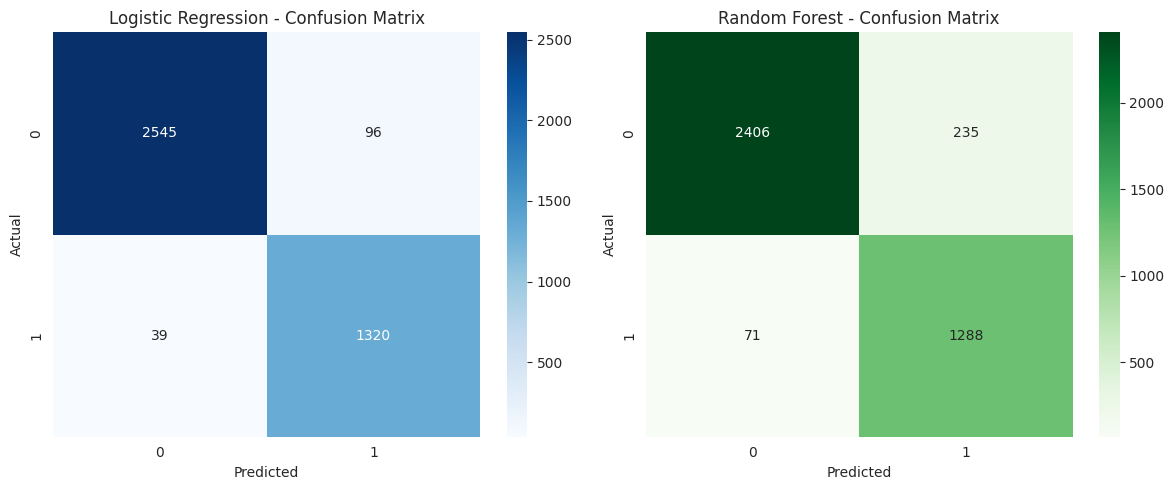

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Logistic Regression - Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Random Forest - Confusion Matrix")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120)
plt.show()

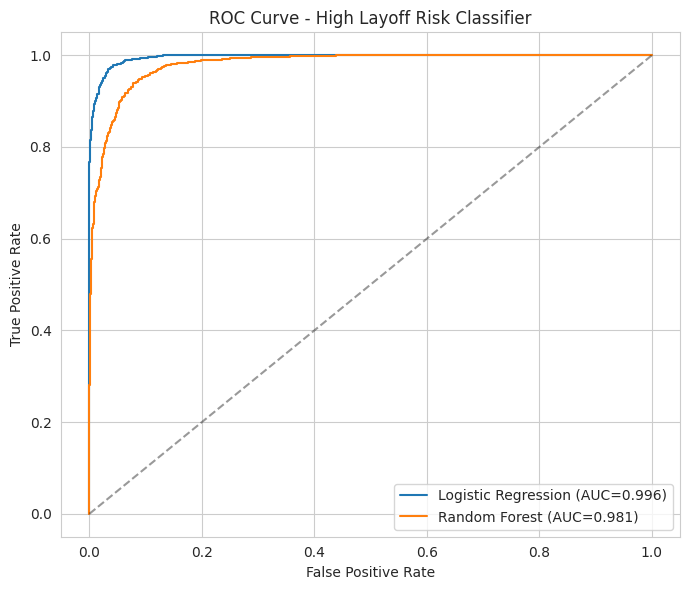

In [15]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})")
plt.plot([0,1], [0,1], 'k--', alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - High Layoff Risk Classifier")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=120)
plt.show()

## 9. Feature importance (Random Forest)

In [16]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(15)

Automation_Exposure_Ratio     0.228345
Routine_Task_Percentage       0.182498
Creativity_Requirement        0.122995
Tasks_Automated_Percentage    0.110983
Job_Level_enc                 0.071734
AI_Usage_Hours_Per_Week       0.045793
AI_Adoption_Level_enc         0.045385
AI_Training_Hours             0.039574
Number_of_AI_Tools_Used       0.032429
Education_Level_enc           0.023260
Years_of_Experience           0.018859
Human_Interaction_Level       0.015116
Industry_Healthcare           0.008917
Age                           0.008649
Industry_Manufacturing        0.007367
dtype: float64

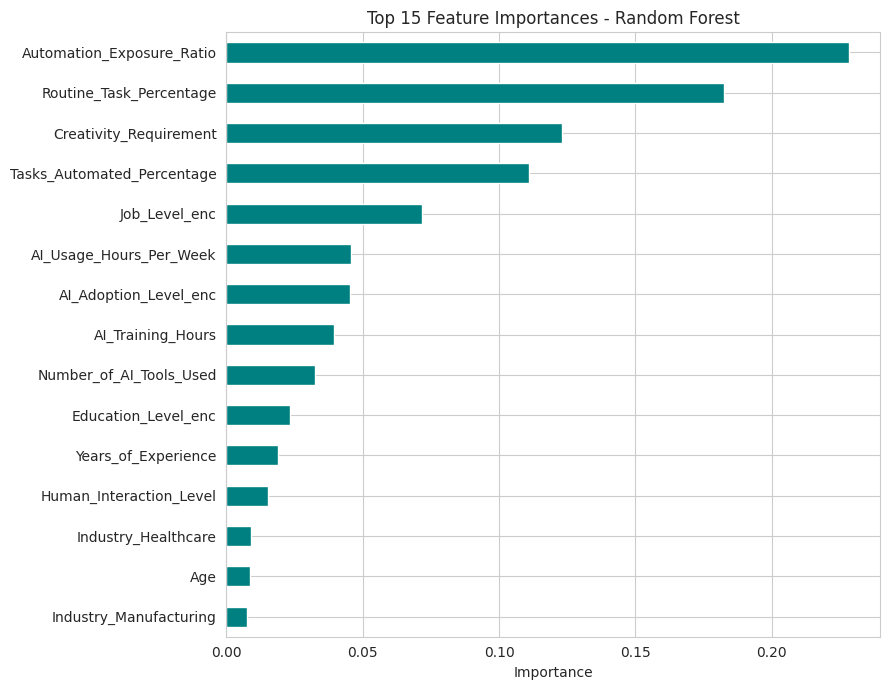

In [17]:
plt.figure(figsize=(9, 7))
importances.head(15).sort_values().plot(kind='barh', color='teal')
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120)
plt.show()

**Top drivers of high layoff risk:** `Automation_Exposure_Ratio` (engineered feature), `Routine_Task_Percentage`,
and `Creativity_Requirement` dominate — consistent with the intuitive story that highly routine, low-creativity,
highly-automatable roles carry the most risk.


## 10. Export predictions for SQL / Power BI

We use `cross_val_predict` (5-fold) rather than predicting on the same data the model was trained on.
Predicting on training data gives artificially perfect-looking results (data leakage) — `cross_val_predict`
ensures every row's prediction comes from a fold where that row was held out, i.e. genuine out-of-sample
predictions, safe to present and discuss in an interview.


In [18]:
rf_full = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=-1
)
oof_probs = cross_val_predict(rf_full, X, y, cv=5, method='predict_proba', n_jobs=-1)[:, 1]
oof_preds = (oof_probs >= 0.5).astype(int)

powerbi_export = df.copy()
powerbi_export['Predicted_Risk_Score'] = (oof_probs * 100).round(2)
powerbi_export['Predicted_High_Risk'] = oof_preds
powerbi_export['Prediction_Match'] = (powerbi_export['Predicted_High_Risk'] == powerbi_export['High_Risk_Flag']).astype(int)

powerbi_export.to_csv("powerbi_dataset.csv", index=False)

print(f"Out-of-sample accuracy: {powerbi_export['Prediction_Match'].mean():.3f}")
powerbi_export.head()

Out-of-sample accuracy: 0.924


,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk,High_Risk_Flag,Predicted_Risk_Score,Predicted_High_Risk,Prediction_Match
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High,1,56.55,1,1
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low,0,1.16,0,1
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low,0,0.07,0,1
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High,1,98.46,1,1
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium,0,16.18,0,1


## Summary

| Model | ROC-AUC |
|---|---|
| Logistic Regression | 0.996 |
| Random Forest | 0.981 |

**Out-of-sample accuracy (5-fold cross-validated):** ~92.4%

**Top 3 drivers of high layoff risk:** `Automation_Exposure_Ratio`, `Routine_Task_Percentage`, `Creativity_Requirement`

**Caveat:** Given how cleanly separable the classes are, this dataset likely encodes an explicit (synthetic) rule
linking automation/routine-task features to risk labels. These results demonstrate the modeling workflow and
evaluation rigor (train/test split, class imbalance handling, cross-validated out-of-sample predictions, feature
importance) rather than real-world predictive validity.

**Next steps:** the cleaned dataset (`cleaned_dataset_with_binary_target.csv`) feeds into SQL analysis (PostgreSQL),
and `powerbi_dataset.csv` feeds into the Power BI dashboard.
